## Quick Research project : quick research summary previous notebook  +  new research

In [1]:
print('Earlier Notebook + new research for app(Dasboard)!!')
%pwd

Earlier Notebook + new research for app(Dasboard)!!


'e:\\dsProject\\customerSegmentation\\research'

In [2]:
import pandas as pd
pd.set_option('display.max_columns', 999)
import os

In [3]:
os.chdir('../')
%pwd

'e:\\dsProject\\customerSegmentation'

# Import data

In [4]:
df = pd.read_csv('data/online_retail_II.csv')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,12/01/2009 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,12/01/2009 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,12/01/2009 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,12/01/2009 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,12/01/2009 07:45:00,1.25,13085.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      525461 non-null  object 
 1   StockCode    525461 non-null  object 
 2   Description  522533 non-null  object 
 3   Quantity     525461 non-null  int64  
 4   InvoiceDate  525461 non-null  object 
 5   Price        525461 non-null  float64
 6   Customer ID  417534 non-null  float64
 7   Country      525461 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.1+ MB


## Data Cleaning

 Cancelled order remove

In [6]:
df['Invoice'].str.startswith('C').sum()
df=df[~df['Invoice'].str.startswith('C',na=False)]


In [7]:
df.shape

(515255, 8)

In [8]:
df=df.dropna()

In [9]:
df.shape

(407695, 8)

In [10]:
df.duplicated().sum()

np.int64(6748)

In [11]:
df=df.drop_duplicates()

Univariate Analyisis
* Max *Quantity* set outlier cut,after analyzing above 329 quantity data is NAN & we need romove above value

In [12]:
df_clean=df[df['Quantity']<329]

In [13]:
df_clean['Description'].astype(str)

df_clean=df_clean[~df_clean['Description'].isin(['Manual','Postage','POSTAGE','CARRIAGE','Bank Charges','Bank Charges','This is a test product.','Discount'])]

In [14]:
discardStockCode=['BANK CHARGES','PADS','ADJUST','ADJUST2','SP1002']

for discardK in discardStockCode:
    df_clean=df_clean[~df_clean['StockCode'].astype(str).str.contains(discardK)]

In [15]:
df_clean.shape

(398580, 8)

In [16]:
df_clean=df_clean[df_clean['Price']>0.0]

* data time


In [17]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'], format='mixed', errors='coerce')

In [18]:
print(f'Start Date: {df['InvoiceDate'].max()}')
print(f'Last Date: {df['InvoiceDate'].min()}')


Start Date: 12/23/2009 16:58:00
Last Date: 01/04/2010 09:24:00


## Feature Engineering

* Total Price(TotalSum)

In [19]:
df_clean['TotalSum']=df_clean['Price']*df_clean['Quantity']

In [20]:
df_clean['InvoiceDate']=pd.to_datetime(df_clean['InvoiceDate'])

In [21]:
df_clean.shape

(398553, 9)

## Feature Enginering
* Date Range

In [22]:
print(f"Last Date : {df_clean['InvoiceDate'].max()} \nStarting Date: {df_clean['InvoiceDate'].min()}")

Last Date : 2010-12-09 20:01:00 
Starting Date: 2009-12-01 07:45:00


In [23]:
df_clean['hours']=df_clean['InvoiceDate'].dt.hour
df_clean['weeks']=df_clean['InvoiceDate'].dt.day_of_week
df_clean['month']=df_clean['InvoiceDate'].dt.month
df_clean['year']=df_clean['InvoiceDate'].dt.year

In [24]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSum,hours,weeks,month,year
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,7,1,12,2009
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,1,12,2009
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,1,12,2009
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,7,1,12,2009
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,7,1,12,2009


In [25]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 398553 entries, 0 to 525460
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      398553 non-null  object        
 1   StockCode    398553 non-null  object        
 2   Description  398553 non-null  object        
 3   Quantity     398553 non-null  int64         
 4   InvoiceDate  398553 non-null  datetime64[ns]
 5   Price        398553 non-null  float64       
 6   Customer ID  398553 non-null  float64       
 7   Country      398553 non-null  object        
 8   TotalSum     398553 non-null  float64       
 9   hours        398553 non-null  int32         
 10  weeks        398553 non-null  int32         
 11  month        398553 non-null  int32         
 12  year         398553 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(4), int64(1), object(4)
memory usage: 36.5+ MB


### Aggregated Data : RFM

In [26]:
# Creating new Data based(RFM) on Customer ID 
aggregated_df=df_clean.groupby('Customer ID').agg(MonetaryValue=('TotalSum','sum'),
                                                  Frequency=('Invoice','nunique'),
                                                  LastInvoiceDate=('InvoiceDate','max')
                                                  ).reset_index()
aggregated_df.head()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate
0,12346.0,169.36,2,2010-06-28 13:53:00
1,12347.0,1323.32,2,2010-12-07 14:57:00
2,12348.0,221.16,1,2010-09-27 14:59:00
3,12349.0,2221.14,2,2010-10-28 08:23:00
4,12351.0,300.93,1,2010-11-29 15:23:00


In [27]:
# Maximum date finding
max_invoice_date=aggregated_df['LastInvoiceDate'].max()
# max_invoice_date
aggregated_df['Recency']=(max_invoice_date-aggregated_df['LastInvoiceDate']).dt.days
aggregated_df.head()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
0,12346.0,169.36,2,2010-06-28 13:53:00,164
1,12347.0,1323.32,2,2010-12-07 14:57:00,2
2,12348.0,221.16,1,2010-09-27 14:59:00,73
3,12349.0,2221.14,2,2010-10-28 08:23:00,42
4,12351.0,300.93,1,2010-11-29 15:23:00,10


### IQR for RFM
Removing Outliers from **aggregated_df**
* Monetary value IQR

In [28]:
M_Q1=aggregated_df['MonetaryValue'].quantile(0.25)
M_Q3=aggregated_df['MonetaryValue'].quantile(0.75)
M_IQR=M_Q3 - M_Q1

monetary_outliers_df=aggregated_df[(aggregated_df['MonetaryValue']>(M_Q3+1.5*M_IQR)) | (aggregated_df['MonetaryValue']<(M_Q1-1.5*M_IQR))].copy()
monetary_outliers_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
9,12357.0,11229.99,1,2010-11-16 10:05:00,23
25,12380.0,4782.84,4,2010-08-31 14:54:00,100
42,12409.0,12346.62,4,2010-10-15 10:24:00,55
48,12415.0,19131.24,4,2010-11-29 15:07:00,10
61,12431.0,4145.52,11,2010-12-01 10:03:00,8
...,...,...,...,...,...
4223,18226.0,6324.43,15,2010-11-26 15:51:00,13
4227,18231.0,4776.50,23,2010-10-29 14:17:00,41
4236,18245.0,3757.92,13,2010-11-25 16:52:00,14
4239,18251.0,9712.64,6,2010-08-20 12:28:00,111


* Fequency

In [29]:
F_Q1=aggregated_df['Frequency'].quantile(0.25)
F_Q3=aggregated_df['Frequency'].quantile(0.75)
F_IQR=F_Q3-F_Q1

frequency_outliers=aggregated_df[(aggregated_df['Frequency']>(F_Q3+1.5*F_IQR)) | (aggregated_df['Frequency']<(F_Q1-1.5*F_IQR))].copy()
frequency_outliers.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,274.000000,274.000000,274.000000,274,274.000000
mean,15350.565693,13094.326679,23.675182,2010-11-23 05:25:39.416058112,16.324818
min,12437.000000,1091.440000,12.000000,2010-05-12 16:51:00,0.000000
25%,13809.250000,4296.230000,13.000000,2010-11-21 10:52:15,2.000000
50%,15411.500000,6225.670000,17.000000,2010-12-02 10:42:30,7.000000
75%,16806.000000,11363.575000,23.000000,2010-12-07 12:03:45,18.000000
max,18260.000000,241958.050000,183.000000,2010-12-09 19:32:00,211.000000
std,1741.417175,26008.754213,21.663096,NaN,27.255412


Normal Data:non Outlier data(data-(MIQR,FIQR))

In [30]:
non_outlier_df=aggregated_df[(~aggregated_df.index.isin(monetary_outliers_df.index)) & (~aggregated_df.index.isin(frequency_outliers.index))]
non_outlier_df.describe()

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
count,3801.000000,3801.000000,3801.000000,3801,3801.000000
mean,15377.171008,871.126940,2.864772,2010-09-03 07:37:05.540647168,97.234675
min,12346.000000,1.550000,1.000000,2009-12-01 10:49:00,0.000000
25%,13909.000000,274.800000,1.000000,2010-07-08 14:18:00,22.000000
50%,15390.000000,575.370000,2.000000,2010-10-12 14:14:00,58.000000
75%,16856.000000,1248.090000,4.000000,2010-11-17 13:14:00,154.000000
max,18287.000000,3721.450000,11.000000,2010-12-09 20:01:00,373.000000
std,1693.397111,803.840929,2.252863,NaN,98.153822


In [31]:
non_outlier_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
0,12346.0,169.36,2,2010-06-28 13:53:00,164
1,12347.0,1323.32,2,2010-12-07 14:57:00,2
2,12348.0,221.16,1,2010-09-27 14:59:00,73
3,12349.0,2221.14,2,2010-10-28 08:23:00,42
4,12351.0,300.93,1,2010-11-29 15:23:00,10
...,...,...,...,...,...
4266,18283.0,619.37,6,2010-11-22 15:30:00,17
4267,18284.0,411.68,1,2010-10-04 11:33:00,66
4268,18285.0,377.00,1,2010-02-17 10:24:00,295
4269,18286.0,1246.43,2,2010-08-20 11:57:00,111


__Feature Transform__: Pretty helpful for finding right number of clusters & their labels
* **Log Transform:**(Monetary ,Frequency)

In [32]:
# log tranasform
import numpy as np

non_outlier_df['MonetaryValue_lg']=np.log1p(non_outlier_df['MonetaryValue'])
non_outlier_df['Frequency_lg']=np.log1p(non_outlier_df['Frequency'])
non_outlier_df

C:\Users\MANN\AppData\Local\Temp\ipykernel_8344\3311062355.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_outlier_df['MonetaryValue_lg']=np.log1p(non_outlier_df['MonetaryValue'])
C:\Users\MANN\AppData\Local\Temp\ipykernel_8344\3311062355.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_outlier_df['Frequency_lg']=np.log1p(non_outlier_df['Frequency'])


,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,MonetaryValue_lg,Frequency_lg
0,12346.0,169.36,2,2010-06-28 13:53:00,164,5.137914,1.098612
1,12347.0,1323.32,2,2010-12-07 14:57:00,2,7.188654,1.098612
2,12348.0,221.16,1,2010-09-27 14:59:00,73,5.403398,0.693147
3,12349.0,2221.14,2,2010-10-28 08:23:00,42,7.706226,1.098612
4,12351.0,300.93,1,2010-11-29 15:23:00,10,5.710195,0.693147
...,...,...,...,...,...,...,...
4266,18283.0,619.37,6,2010-11-22 15:30:00,17,6.430316,1.945910
4267,18284.0,411.68,1,2010-10-04 11:33:00,66,6.022672,0.693147
4268,18285.0,377.00,1,2010-02-17 10:24:00,295,5.934894,0.693147
4269,18286.0,1246.43,2,2010-08-20 11:57:00,111,7.128841,1.098612


In [33]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
scaled_data=sc.fit_transform(non_outlier_df[['MonetaryValue_lg','Frequency_lg','Recency']])

scaled_data

array([[-1.14589952, -0.22467421,  0.68030065],
       [ 0.84660349, -0.22467421, -0.97038712],
       [-0.88795482, -1.02405361, -0.24693754],
       ...,
       [-0.37155206, -1.02405361,  2.01511608],
       [ 0.78848841, -0.22467421,  0.14026082],
       [ 1.38154654,  0.78242473, -0.81754566]])

In [34]:
scaled_df=pd.DataFrame(data=scaled_data,index=non_outlier_df.index,columns=('MonetaryValue','Frequency','Recency'))

scaled_df

,MonetaryValue,Frequency,Recency
0,-1.145900,-0.224674,0.680301
1,0.846603,-0.224674,-0.970387
2,-0.887955,-1.024054,-0.246938
3,1.349477,-0.224674,-0.562810
4,-0.589870,-1.024054,-0.888872
...,...,...,...
4266,0.109801,1.445784,-0.817546
4267,-0.286267,-1.024054,-0.318264
4268,-0.371552,-1.024054,2.015116
4269,0.788488,-0.224674,0.140261


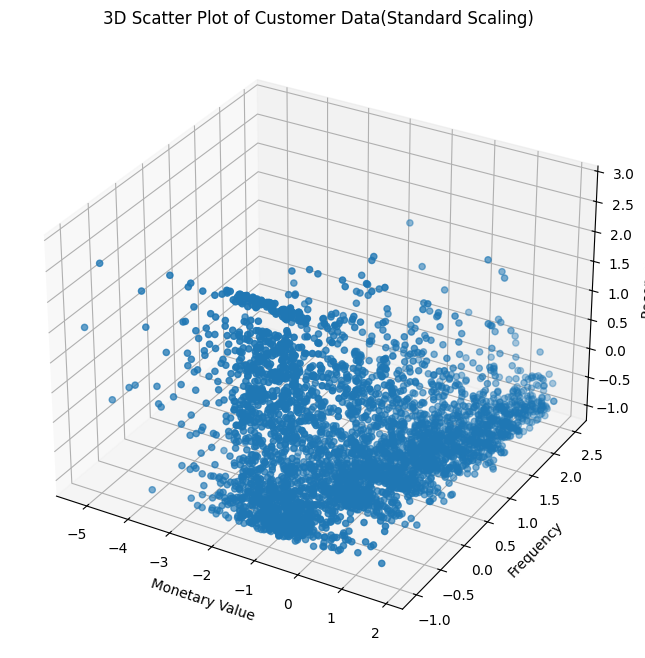

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
fig=plt.figure(figsize=(8,8))
ax=fig.add_subplot(projection='3d')
scatter=ax.scatter(scaled_df['MonetaryValue'],scaled_df['Frequency'],scaled_df['Recency'])

ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')
ax.set_title('3D Scatter Plot of Customer Data(Standard Scaling)')

plt.show()

# K Means CLustering

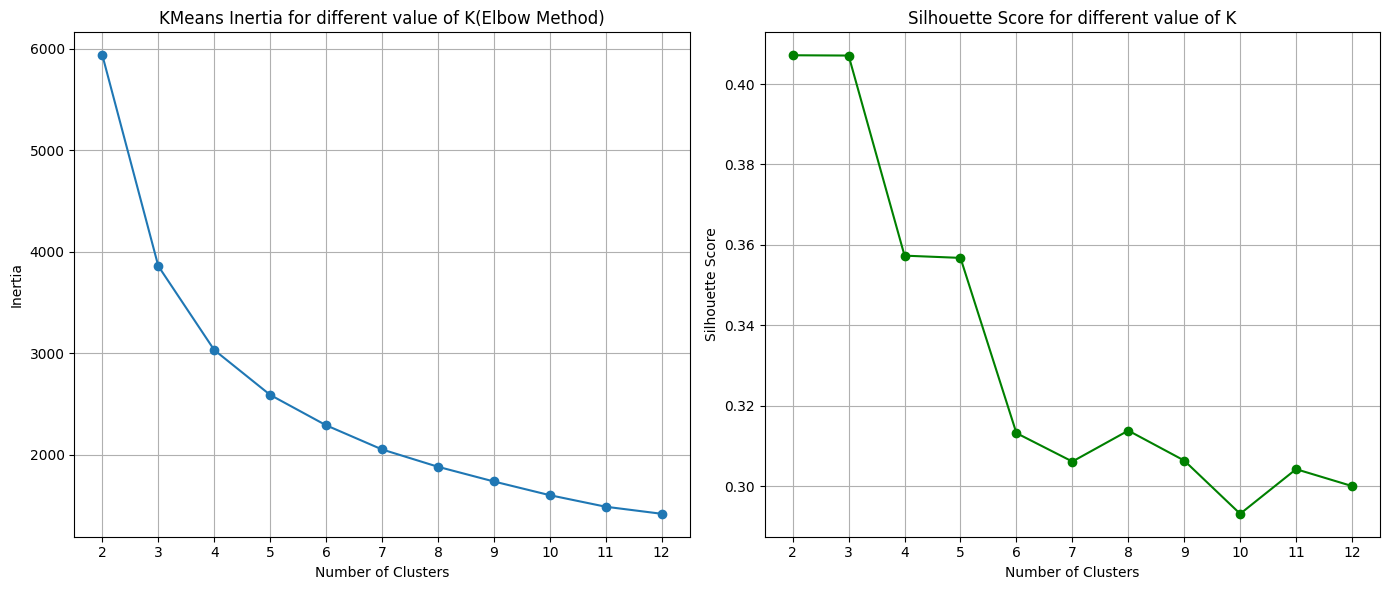

In [36]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
max_k=12 #big number of cluseter(assume)

inertia=[]
silhoutte_scores=[]
k_values=range(2,max_k+1) #max_k+1:cause last value is exclusive in range()

for k in k_values:
    k_means=KMeans(n_clusters=k,random_state=42,max_iter=1000)

    cluster_labels=k_means.fit_predict(scaled_df)

    sil_score=silhouette_score(scaled_df,cluster_labels)
    silhoutte_scores.append(sil_score)

    inertia.append(k_means.inertia_)


# visualization
# Inertia KMeans
plt.figure(figsize=(14,6))


plt.subplot(1,2,1)
plt.plot(k_values,inertia,marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.title('KMeans Inertia for different value of K(Elbow Method)')
plt.grid(True)

# Silhotte score
plt.subplot(1,2,2)
plt.plot(k_values,silhoutte_scores,marker='o',color='green')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.title('Silhouette Score for different value of K')
plt.grid(True)

plt.tight_layout()
plt.show()

In [37]:
kmeans=KMeans(n_clusters=3,random_state=42,max_iter=1000)   
cluster_labels=kmeans.fit_predict(scaled_df)
cluster_labels

array([1, 0, 2, ..., 1, 0, 0], dtype=int32)

In [38]:
non_outlier_df['Cluster']=cluster_labels

C:\Users\MANN\AppData\Local\Temp\ipykernel_8344\3044991670.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_outlier_df['Cluster']=cluster_labels


In [39]:
non_outlier_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,MonetaryValue_lg,Frequency_lg,Cluster
0,12346.0,169.36,2,2010-06-28 13:53:00,164,5.137914,1.098612,1
1,12347.0,1323.32,2,2010-12-07 14:57:00,2,7.188654,1.098612,0
2,12348.0,221.16,1,2010-09-27 14:59:00,73,5.403398,0.693147,2
3,12349.0,2221.14,2,2010-10-28 08:23:00,42,7.706226,1.098612,0
4,12351.0,300.93,1,2010-11-29 15:23:00,10,5.710195,0.693147,2
...,...,...,...,...,...,...,...,...
4266,18283.0,619.37,6,2010-11-22 15:30:00,17,6.430316,1.945910,0
4267,18284.0,411.68,1,2010-10-04 11:33:00,66,6.022672,0.693147,2
4268,18285.0,377.00,1,2010-02-17 10:24:00,295,5.934894,0.693147,1
4269,18286.0,1246.43,2,2010-08-20 11:57:00,111,7.128841,1.098612,0


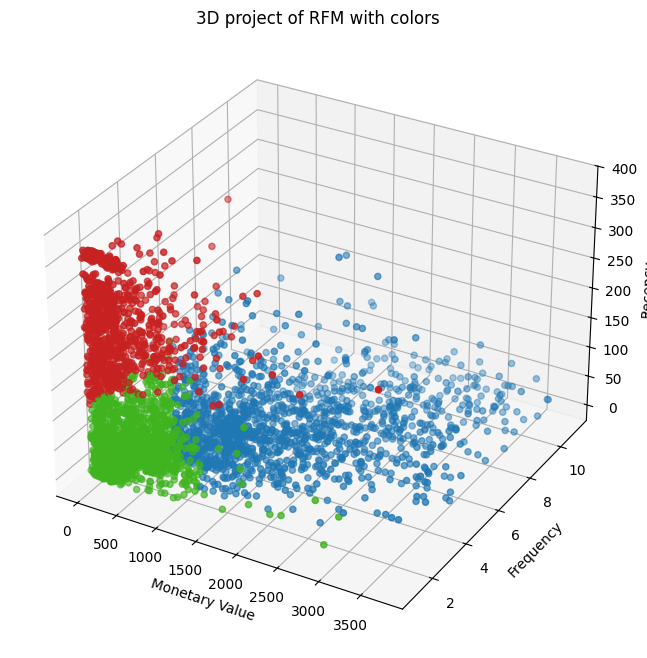

In [40]:
# assigning cluster  to CLusters
cluster_color={0:'#1f77b4',
               1:"#c82121",
               2:"#3fb41f"
               }
colors=non_outlier_df['Cluster'].map(cluster_color)
fig=plt.figure(figsize=(8,8))
ax=fig.add_subplot(projection='3d')
scatter=ax.scatter(non_outlier_df['MonetaryValue'],
                   non_outlier_df['Frequency'],
                   non_outlier_df['Recency'],
                   c=colors,
                   marker='o')
ax.set_xlabel('Monetary Value')
ax.set_ylabel('Frequency')
ax.set_zlabel('Recency')
ax.set_title('3D project of RFM with colors')
plt.show()

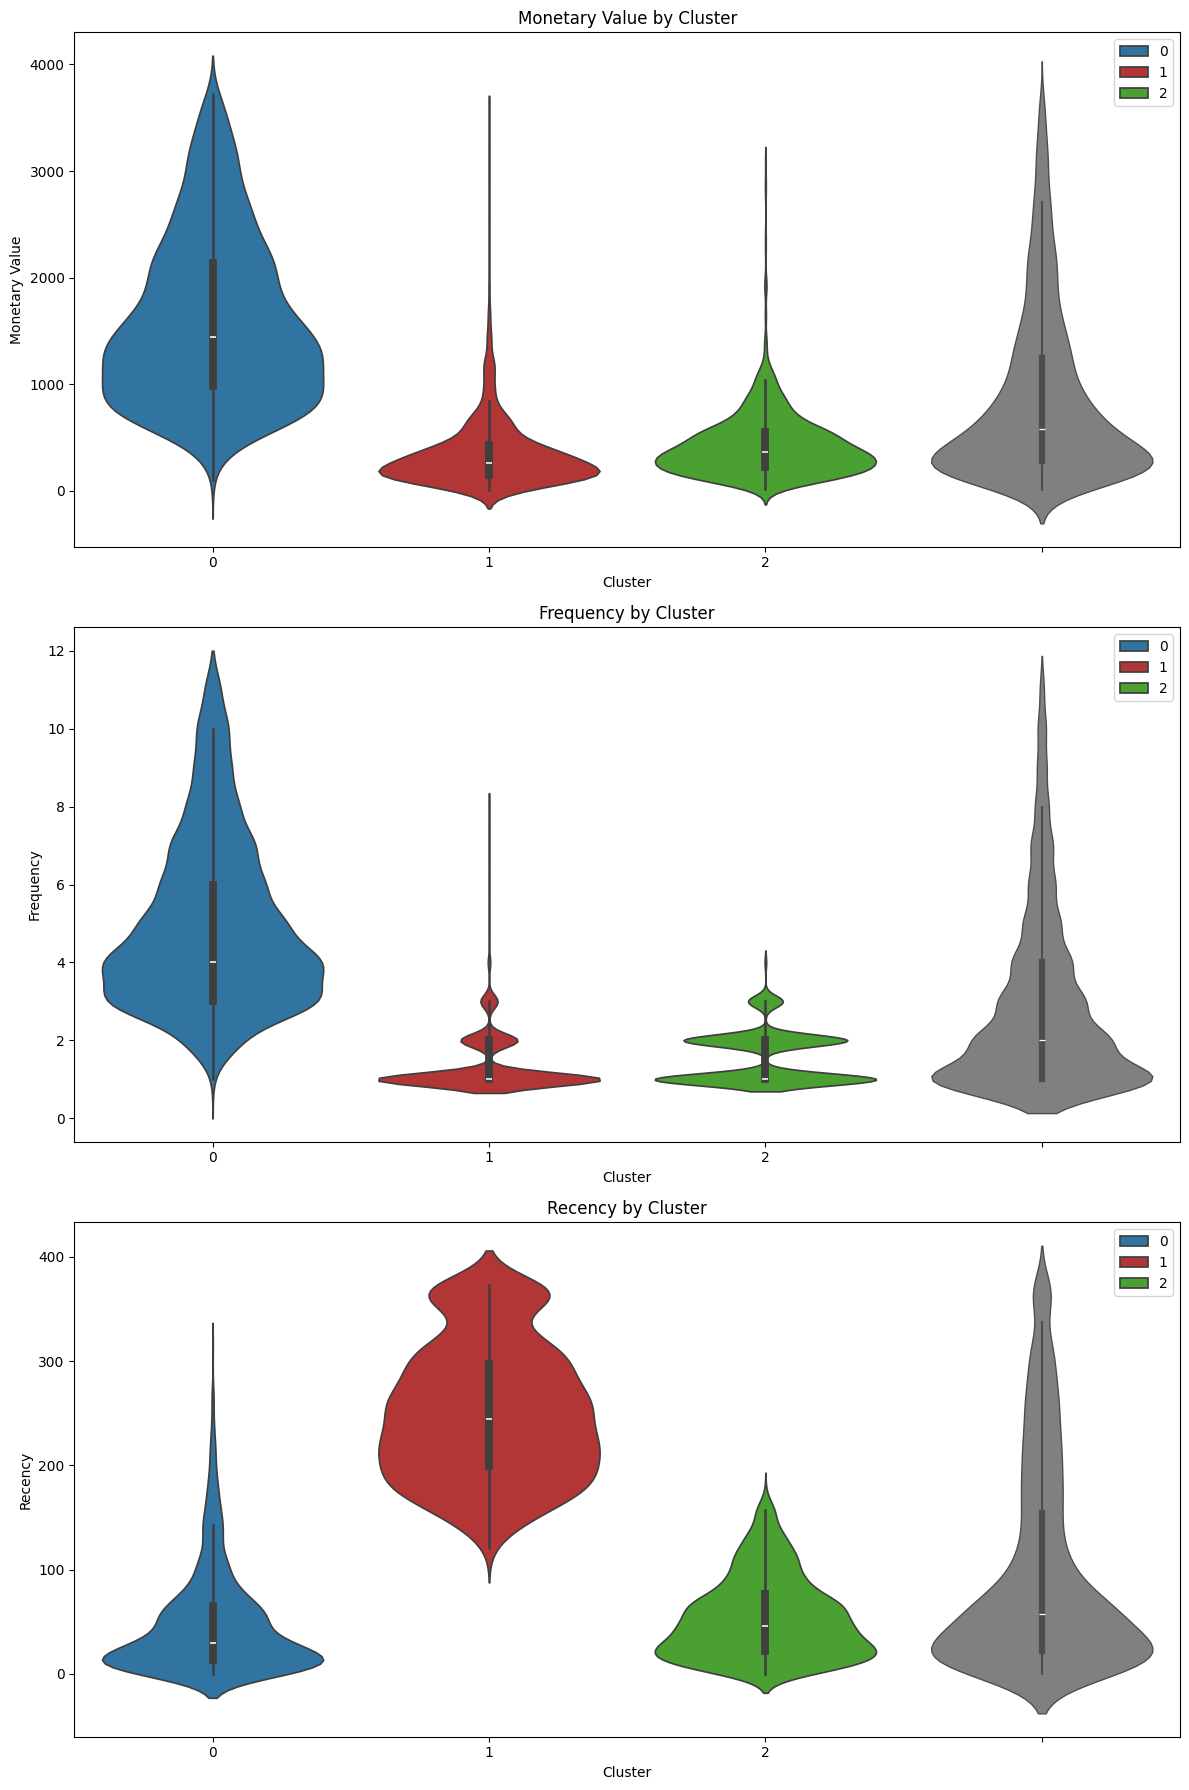

In [41]:
plt.figure(figsize=(12,18))

plt.subplot(3,1,1)
sns.violinplot(x=non_outlier_df['Cluster'],y=non_outlier_df['MonetaryValue'],palette=cluster_color,hue=non_outlier_df['Cluster'])
sns.violinplot(y=non_outlier_df['MonetaryValue'],color='gray',linewidth=1.0)
plt.title('Monetary Value by Cluster')
plt.ylabel('Monetary Value')


plt.subplot(3,1,2)
sns.violinplot(x=non_outlier_df['Cluster'],y=non_outlier_df['Frequency'],palette=cluster_color,hue=non_outlier_df['Cluster'])
sns.violinplot(y=non_outlier_df['Frequency'],color='gray',linewidth=1.0)
plt.title('Frequency by Cluster')
plt.ylabel('Frequency')

plt.subplot(3,1,3)
sns.violinplot(x=non_outlier_df['Cluster'],y=non_outlier_df['Recency'],palette=cluster_color,hue=non_outlier_df['Cluster'])
sns.violinplot(y=non_outlier_df['Recency'],color='gray',linewidth=1.0)
plt.title('Recency by Cluster')
plt.ylabel('Recency')

plt.tight_layout()
plt.show()

In [42]:
non_outlier_df['Cluster'].value_counts()

Cluster
0    1494
2    1424
1     883
Name: count, dtype: int64

## Outlier DataFrame

In [43]:
overlap_indices=monetary_outliers_df.index.intersection(frequency_outliers.index)

# seperating OUTLIERS INTO 3 CATEGORIES
monetary_only_outliers=monetary_outliers_df.drop(overlap_indices)
frequency_only_outliers=frequency_outliers.drop(overlap_indices)
monetary_frequency_outliers=monetary_outliers_df.loc[overlap_indices]

# Assigning cluster
monetary_only_outliers['Cluster']= -1 #Monetary
frequency_only_outliers['Cluster']= -2 #Frequency
monetary_frequency_outliers['Cluster']= -3 #OVerlap

outlier_cluster_df=pd.concat([monetary_only_outliers,frequency_only_outliers,monetary_frequency_outliers])
outlier_cluster_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,Cluster
9,12357.0,11229.99,1,2010-11-16 10:05:00,23,-1
25,12380.0,4782.84,4,2010-08-31 14:54:00,100,-1
42,12409.0,12346.62,4,2010-10-15 10:24:00,55,-1
48,12415.0,19131.24,4,2010-11-29 15:07:00,10,-1
61,12431.0,4145.52,11,2010-12-01 10:03:00,8,-1
...,...,...,...,...,...,...
4222,18225.0,7539.84,15,2010-12-09 15:46:00,0,-3
4223,18226.0,6324.43,15,2010-11-26 15:51:00,13,-3
4227,18231.0,4776.50,23,2010-10-29 14:17:00,41,-3
4236,18245.0,3757.92,13,2010-11-25 16:52:00,14,-3


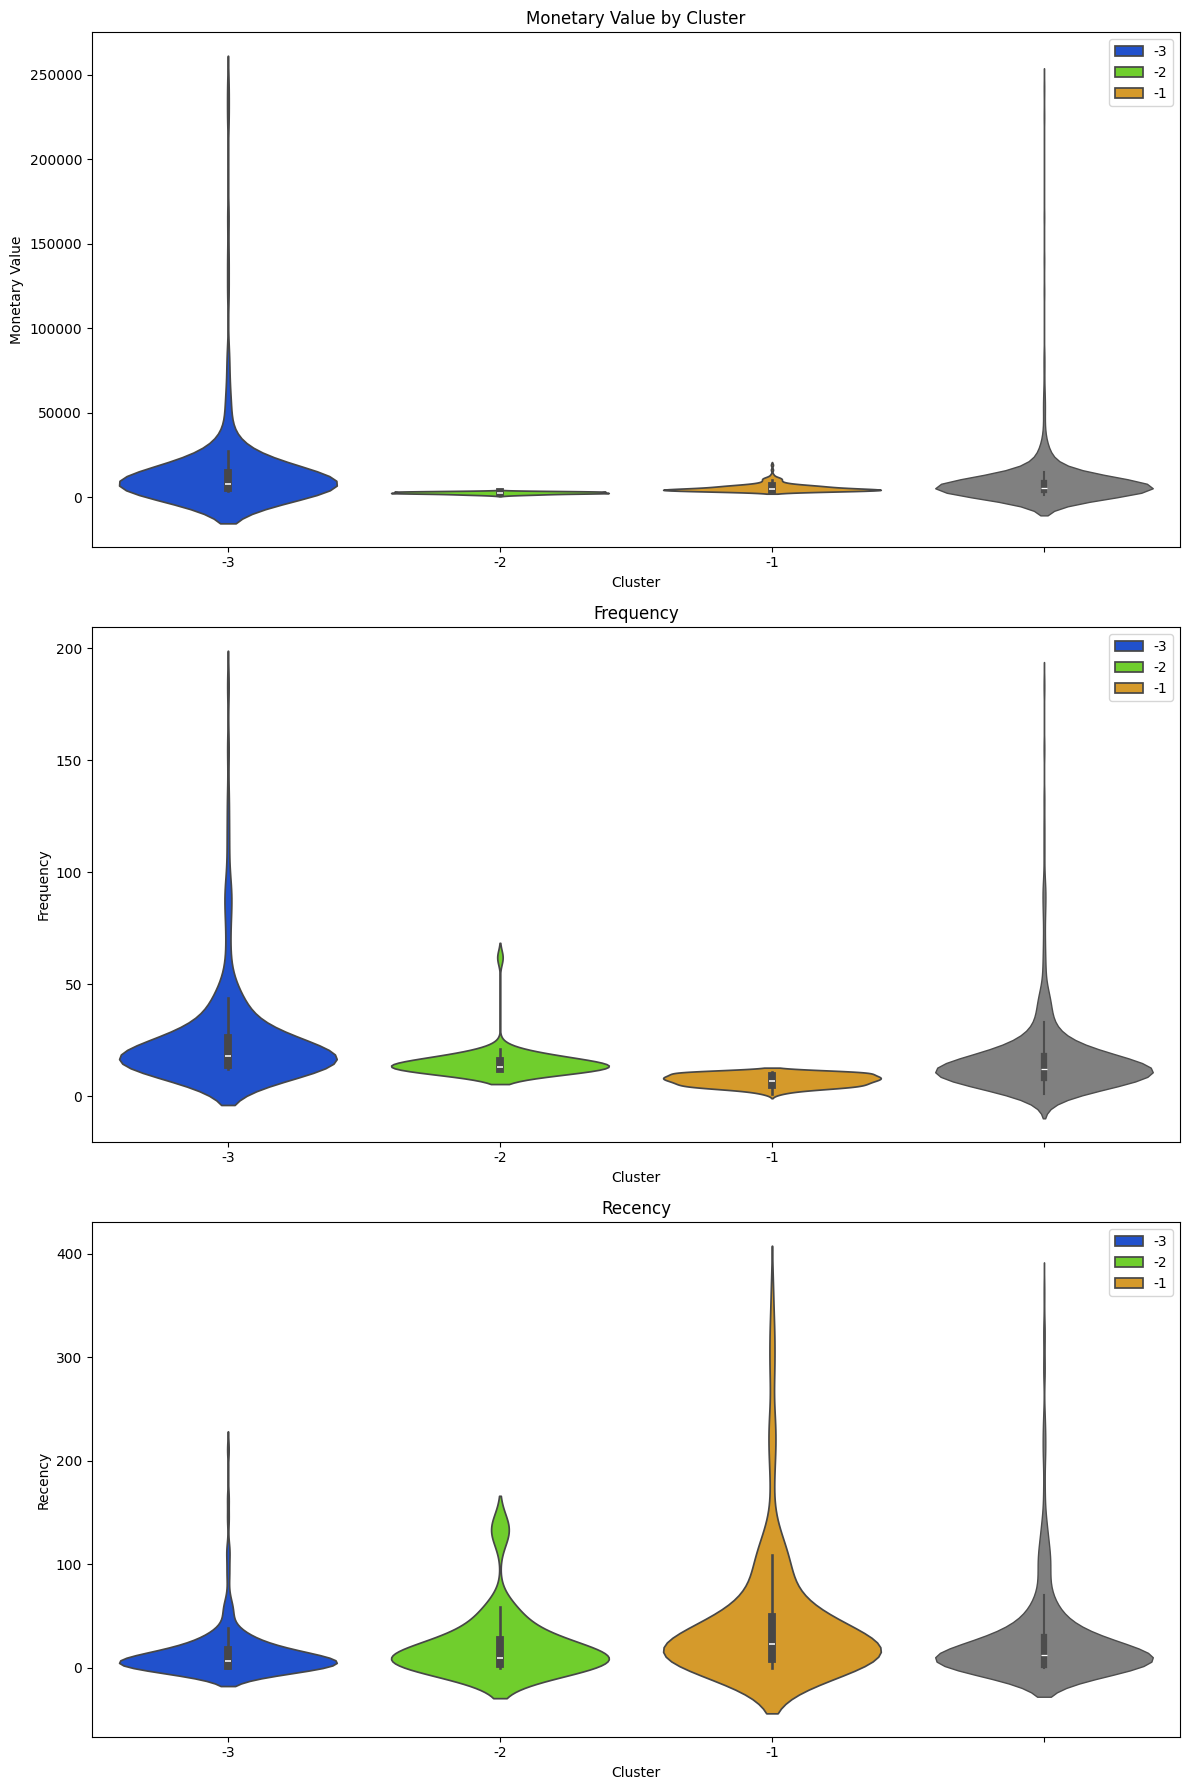

In [44]:
cluster_color={-1: "#f2a20e",
               -2:"#6ce912fd",
               -3:"#0445e9"
               }

plt.figure(figsize=(12,18))

plt.subplot(3,1,1)
sns.violinplot(x=outlier_cluster_df['Cluster'],y=outlier_cluster_df['MonetaryValue'],palette=cluster_color,hue=outlier_cluster_df['Cluster'])
sns.violinplot(y=outlier_cluster_df['MonetaryValue'],color='gray',linewidth=1.0)
plt.title('Monetary Value by Cluster')
plt.ylabel('Monetary Value')

plt.subplot(3,1,2)
sns.violinplot(x=outlier_cluster_df['Cluster'],y=outlier_cluster_df['Frequency'],palette=cluster_color,hue=outlier_cluster_df['Cluster'])
sns.violinplot(y=outlier_cluster_df['Frequency'],color='gray',linewidth=1.0)
plt.title('Frequency')


plt.subplot(3,1,3)
sns.violinplot(x=outlier_cluster_df['Cluster'],y=outlier_cluster_df['Recency'],palette=cluster_color,hue=outlier_cluster_df['Cluster'])
sns.violinplot(y=outlier_cluster_df['Recency'],color='gray',linewidth=1.0)
plt.title('Recency')


plt.tight_layout()
plt.show()

In [45]:
outlier_cluster_df['Frequency'].agg(max)

C:\Users\MANN\AppData\Local\Temp\ipykernel_8344\2893107720.py:1: FutureWarning: The provided callable <built-in function max> is currently using Series.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  outlier_cluster_df['Frequency'].agg(max)


np.int64(183)

### Mapping Cluster with Customer Segmented name

In [46]:
cluster_labels_mapping={
    0:'Champions/VIPs',
    1:'At-Risk / Lost Customers',
    2:'New / Promising Customers',
    -1:'Hibernating / Risk of Churn',
    -2:'Loyal Everyday Shoppers',
    -3:'Enterprise / VIP Whales'
}

all CLuster = Non outlier DF + outlier CLuster Df

In [47]:
all_cluster_df=pd.concat([non_outlier_df,outlier_cluster_df])
print('All Cluster Dataset: \n',all_cluster_df.head())
print('Cluster Value Counts: \n',all_cluster_df['Cluster'].value_counts())

All Cluster Dataset: 
    Customer ID  MonetaryValue  Frequency     LastInvoiceDate  Recency  \
0      12346.0         169.36          2 2010-06-28 13:53:00      164   
1      12347.0        1323.32          2 2010-12-07 14:57:00        2   
2      12348.0         221.16          1 2010-09-27 14:59:00       73   
3      12349.0        2221.14          2 2010-10-28 08:23:00       42   
4      12351.0         300.93          1 2010-11-29 15:23:00       10   

   MonetaryValue_lg  Frequency_lg  Cluster  
0          5.137914      1.098612        1  
1          7.188654      1.098612        0  
2          5.403398      0.693147        2  
3          7.706226      1.098612        0  
4          5.710195      0.693147        2  
Cluster Value Counts: 
 Cluster
 0    1494
 2    1424
 1     883
-3     223
-1     196
-2      51
Name: count, dtype: int64


In [48]:
all_cluster_df['ClusterLabel']=all_cluster_df['Cluster'].map(cluster_labels_mapping)
print('All CLuster data with Cluster label: \n',all_cluster_df.head())
print('Cluster Labels with Frequency:\n',all_cluster_df['ClusterLabel'].value_counts())

All CLuster data with Cluster label: 
    Customer ID  MonetaryValue  Frequency     LastInvoiceDate  Recency  \
0      12346.0         169.36          2 2010-06-28 13:53:00      164   
1      12347.0        1323.32          2 2010-12-07 14:57:00        2   
2      12348.0         221.16          1 2010-09-27 14:59:00       73   
3      12349.0        2221.14          2 2010-10-28 08:23:00       42   
4      12351.0         300.93          1 2010-11-29 15:23:00       10   

   MonetaryValue_lg  Frequency_lg  Cluster               ClusterLabel  
0          5.137914      1.098612        1   At-Risk / Lost Customers  
1          7.188654      1.098612        0             Champions/VIPs  
2          5.403398      0.693147        2  New / Promising Customers  
3          7.706226      1.098612        0             Champions/VIPs  
4          5.710195      0.693147        2  New / Promising Customers  
Cluster Labels with Frequency:
 ClusterLabel
Champions/VIPs                 1494
New / Pro

In [49]:
aggregated_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency
0,12346.0,169.36,2,2010-06-28 13:53:00,164
1,12347.0,1323.32,2,2010-12-07 14:57:00,2
2,12348.0,221.16,1,2010-09-27 14:59:00,73
3,12349.0,2221.14,2,2010-10-28 08:23:00,42
4,12351.0,300.93,1,2010-11-29 15:23:00,10
...,...,...,...,...,...
4266,18283.0,619.37,6,2010-11-22 15:30:00,17
4267,18284.0,411.68,1,2010-10-04 11:33:00,66
4268,18285.0,377.00,1,2010-02-17 10:24:00,295
4269,18286.0,1246.43,2,2010-08-20 11:57:00,111


In [50]:
all_cluster_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,MonetaryValue_lg,Frequency_lg,Cluster,ClusterLabel
0,12346.0,169.36,2,2010-06-28 13:53:00,164,5.137914,1.098612,1,At-Risk / Lost Customers
1,12347.0,1323.32,2,2010-12-07 14:57:00,2,7.188654,1.098612,0,Champions/VIPs
2,12348.0,221.16,1,2010-09-27 14:59:00,73,5.403398,0.693147,2,New / Promising Customers
3,12349.0,2221.14,2,2010-10-28 08:23:00,42,7.706226,1.098612,0,Champions/VIPs
4,12351.0,300.93,1,2010-11-29 15:23:00,10,5.710195,0.693147,2,New / Promising Customers
...,...,...,...,...,...,...,...,...,...
4222,18225.0,7539.84,15,2010-12-09 15:46:00,0,NaN,NaN,-3,Enterprise / VIP Whales
4223,18226.0,6324.43,15,2010-11-26 15:51:00,13,NaN,NaN,-3,Enterprise / VIP Whales
4227,18231.0,4776.50,23,2010-10-29 14:17:00,41,NaN,NaN,-3,Enterprise / VIP Whales
4236,18245.0,3757.92,13,2010-11-25 16:52:00,14,NaN,NaN,-3,Enterprise / VIP Whales


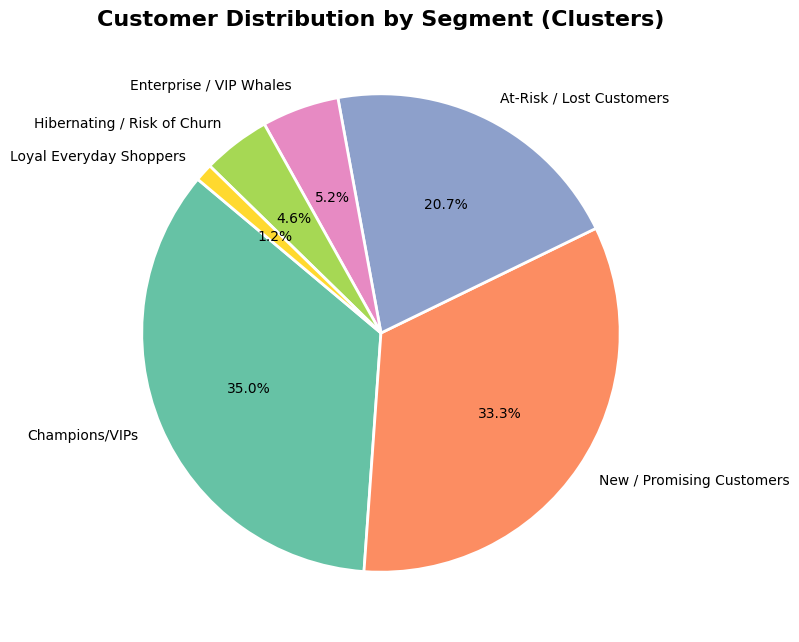

In [51]:
cluster_counts=all_cluster_df['ClusterLabel'].value_counts()

plt.figure(figsize=(8,8))
colors = sns.color_palette('Set2', len(cluster_counts))

plt.pie(
    cluster_counts, 
    labels=cluster_counts.index,   # Label each slice with the cluster name/ID
    autopct='%1.1f%%',            # Display the percentage format on the slice
    startangle=140,                # Rotate the start for a cleaner look
    colors=colors,                 # Match the colors with your scatter plot
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}  # Adds crisp white borders
)
plt.title('Customer Distribution by Segment (Clusters)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [52]:
all_cluster_df

,Customer ID,MonetaryValue,Frequency,LastInvoiceDate,Recency,MonetaryValue_lg,Frequency_lg,Cluster,ClusterLabel
0,12346.0,169.36,2,2010-06-28 13:53:00,164,5.137914,1.098612,1,At-Risk / Lost Customers
1,12347.0,1323.32,2,2010-12-07 14:57:00,2,7.188654,1.098612,0,Champions/VIPs
2,12348.0,221.16,1,2010-09-27 14:59:00,73,5.403398,0.693147,2,New / Promising Customers
3,12349.0,2221.14,2,2010-10-28 08:23:00,42,7.706226,1.098612,0,Champions/VIPs
4,12351.0,300.93,1,2010-11-29 15:23:00,10,5.710195,0.693147,2,New / Promising Customers
...,...,...,...,...,...,...,...,...,...
4222,18225.0,7539.84,15,2010-12-09 15:46:00,0,NaN,NaN,-3,Enterprise / VIP Whales
4223,18226.0,6324.43,15,2010-11-26 15:51:00,13,NaN,NaN,-3,Enterprise / VIP Whales
4227,18231.0,4776.50,23,2010-10-29 14:17:00,41,NaN,NaN,-3,Enterprise / VIP Whales
4236,18245.0,3757.92,13,2010-11-25 16:52:00,14,NaN,NaN,-3,Enterprise / VIP Whales


In [53]:
# Exporting in CSV format
# all_cluster_df.to_csv(r'e:\dsProject\customerSegmentation\data\rfm_Customer_cluster.csv',index=False)

In [54]:
# Exporting Clean Customer Retail data
# df_clean.to_csv(r'e:\dsProject\customerSegmentation\data\clean_Customer_Retail.csv',index=False)

DF = all_cluster_RFM  +  df_clean

In [55]:
cols_name=['Recency', 'Frequency', 'MonetaryValue', 'ClusterLabel','Customer ID'] 
DF=df_clean.merge(all_cluster_df[cols_name],on='Customer ID',how='left')
DF.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSum,hours,weeks,month,year,Recency,Frequency,MonetaryValue,ClusterLabel
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,7,1,12,2009,314,6,2017.2,Champions/VIPs
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,1,12,2009,314,6,2017.2,Champions/VIPs
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,1,12,2009,314,6,2017.2,Champions/VIPs
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,7,1,12,2009,314,6,2017.2,Champions/VIPs
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,7,1,12,2009,314,6,2017.2,Champions/VIPs


Date Conversion: Month conversion numeric to name

In [56]:
# assing number to month name
months_order = {1:'January', 2:'February', 3:'March', 4:'April', 5:'May', 6:'June', 
                7:'July', 8:'August', 9:'September', 10:'October', 11:'November', 12:'December'}

DF['month']=DF['month'].map(months_order)

# assigning number to week names
daysOrder={0:'Monday', 1:'Tuesday', 2:'Wednesday', 3:'Thursday', 4:'Friday', 5:'Saturday', 6:'Sunday'}
DF['weeks']=DF['weeks'].map(daysOrder)

# combining  month + year
DF['month']=DF.apply(lambda data:f'{data['month']}({data['year']})',axis=1)

In [57]:
DF['month'].value_counts()

month
November(2010)     58619
October(2010)      48481
September(2010)    33880
March(2010)        31551
June(2010)         30516
December(2009)     30132
May(2010)          28085
April(2010)        26651
July(2010)         26508
August(2010)       25848
February(2010)     22892
January(2010)      21294
December(2010)     14096
Name: count, dtype: int64

combining name month + year

In [58]:
DF['month'].value_counts()

month
November(2010)     58619
October(2010)      48481
September(2010)    33880
March(2010)        31551
June(2010)         30516
December(2009)     30132
May(2010)          28085
April(2010)        26651
July(2010)         26508
August(2010)       25848
February(2010)     22892
January(2010)      21294
December(2010)     14096
Name: count, dtype: int64

In [59]:
# Exporting DataFRame
# DF.to_csv(r'E:\dsProject\customerSegmentation\data\clean_Customer_RetailNw2.csv',index=False)

In [60]:
DF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398553 entries, 0 to 398552
Data columns (total 17 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Invoice        398553 non-null  object        
 1   StockCode      398553 non-null  object        
 2   Description    398553 non-null  object        
 3   Quantity       398553 non-null  int64         
 4   InvoiceDate    398553 non-null  datetime64[ns]
 5   Price          398553 non-null  float64       
 6   Customer ID    398553 non-null  float64       
 7   Country        398553 non-null  object        
 8   TotalSum       398553 non-null  float64       
 9   hours          398553 non-null  int32         
 10  weeks          398553 non-null  object        
 11  month          398553 non-null  object        
 12  year           398553 non-null  int32         
 13  Recency        398553 non-null  int64         
 14  Frequency      398553 non-null  int64         
 15  

In [61]:
DF['ClusterLabel'].value_counts()

ClusterLabel
Champions/VIPs                 163500
Enterprise / VIP Whales        114710
New / Promising Customers       45843
Hibernating / Risk of Churn     42953
At-Risk / Lost Customers        20599
Loyal Everyday Shoppers         10948
Name: count, dtype: int64

In [62]:
DF.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSum,hours,weeks,month,year,Recency,Frequency,MonetaryValue,ClusterLabel
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,7,Tuesday,December(2009),2009,314,6,2017.2,Champions/VIPs
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,Tuesday,December(2009),2009,314,6,2017.2,Champions/VIPs
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,7,Tuesday,December(2009),2009,314,6,2017.2,Champions/VIPs
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,7,Tuesday,December(2009),2009,314,6,2017.2,Champions/VIPs
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,7,Tuesday,December(2009),2009,314,6,2017.2,Champions/VIPs


# Changes in __Customer Segmented data__
Doing some Changes with Cluster Label [ *Champion/VIPs* , *New/Promising Customers* , *Hibernanating Cutomrs* ]

* __Why?__
Because We found CLustered data(CLUSTER ID).then We clusters segmented(Labeling) into  customer Segmented by visualization Graph(VOilin Graph). Based on pattern we recognize them & assigned them Labels.However,there were some Customer Segmented ,which were not supposed to be in that Customer Segments.Those were lying data in unsual data pattern.<br>
& then we assigned right data points with the right Customer Segmented labels .By doing that,We Got Correct Logical Segmented Customers.
After analyzing those wrong clustered on dashboard  at each Customer Labeled.We analyzed every single Segmented label.Found out wrong Clustered  pattern & then we applied some *Logical Business RULES* on those wrong customer Segmented data points. <br>
KMeans grouped these users here because their high Frequency and Monetary values overwhelmed the Recency dimension. The algorithm saw the massive bubble sizes and high transaction counts and decided they looked more like VIPs than low-value churning customers.<br>
* __Why wrong Customer Segmented happened?__ ML Algo don't see the business rules or logics.ML algo only see patterns ,then it gives outputs. <br>
If you're building ML models for business or real world.There you still have to supervise ML models & checking logics  or rules .so that You could be ensure that your model can be properly  deployed in real world.

In [63]:
novRev=DF[(DF['InvoiceDate'].dt.day>=1) & (DF['InvoiceDate'].dt.day<=9) & (DF['month']=='November(2010)')]
novRev['TotalSum'].sum()

np.float64(306862.0)

In [64]:
decRev=DF[(DF['InvoiceDate'].dt.day>=1) & (DF['InvoiceDate'].dt.day<=9) & (DF['month']=='December(2010)')]
decRev['TotalSum'].sum()

np.float64(271063.3)

In [65]:
DF['ClusterLabel'].value_counts()

ClusterLabel
Champions/VIPs                 163500
Enterprise / VIP Whales        114710
New / Promising Customers       45843
Hibernating / Risk of Churn     42953
At-Risk / Lost Customers        20599
Loyal Everyday Shoppers         10948
Name: count, dtype: int64

In [66]:
chapionCLuster=DF[DF['ClusterLabel']=='Champions/VIPs']
# chapionCLuster[(chapionCLuster['Recency']>90) & chapionCLuster['Customer ID'].unique()]
champCluster=chapionCLuster.drop_duplicates(subset='Customer ID')
champCluster[champCluster['Recency']>90]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalSum,hours,weeks,month,year,Recency,Frequency,MonetaryValue,ClusterLabel
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40,7,Tuesday,December(2009),2009,314,6,2017.20,Champions/VIPs
620,489531,79029,GLASS HONEYPOT WASP CATCHER,1,2009-12-01 11:57:00,1.95,14871.0,United Kingdom,1.95,11,Tuesday,December(2009),2009,128,5,726.89,Champions/VIPs
1229,489567,84352,SILVER CHRISTMAS TREE BAUBLE STAND,2,2009-12-01 13:19:00,16.95,15326.0,United Kingdom,33.90,13,Tuesday,December(2009),2009,244,4,1388.81,Champions/VIPs
1824,489613,22165,"DIAMANTE HEART SHAPED WALL MIRROR,",1,2009-12-01 14:56:00,12.75,13585.0,United Kingdom,12.75,14,Tuesday,December(2009),2009,165,3,684.54,Champions/VIPs
2103,489664,21737,SET 3 WICKER LOG BASKETS,1,2009-12-01 18:03:00,19.95,14061.0,United Kingdom,19.95,18,Tuesday,December(2009),2009,142,3,917.43,Champions/VIPs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198458,515123,22546,MINI JIGSAW FIDO,48,2010-07-08 14:06:00,0.42,12592.0,Germany,20.16,14,Thursday,July(2010),2010,154,2,1322.04,Champions/VIPs
201726,515593,22079,RIBBON REEL HEARTS DESIGN,5,2010-07-13 13:29:00,1.65,16435.0,United Kingdom,8.25,13,Tuesday,July(2010),2010,147,3,1003.07,Champions/VIPs
202830,515782,21843,RED RETROSPOT CAKE STAND,1,2010-07-14 15:34:00,10.95,16172.0,United Kingdom,10.95,15,Wednesday,July(2010),2010,108,3,744.34,Champions/VIPs
209548,516731,22114,HOT WATER BOTTLE TEA AND SYMPATHY,48,2010-07-22 13:39:00,3.45,16555.0,United Kingdom,165.60,13,Thursday,July(2010),2010,140,4,1629.79,Champions/VIPs


**Champion**
it grouped these users here because their high Frequency and Monetary values overwhelmed the Recency dimension. The algorithm saw the massive bubble sizes and high transaction counts and decided they looked more like VIPs than low-value churning customers.

In [67]:
DF['ClusterLabel'].unique()

array(['Champions/VIPs', 'Enterprise / VIP Whales',
       'New / Promising Customers', 'Hibernating / Risk of Churn',
       'At-Risk / Lost Customers', 'Loyal Everyday Shoppers'],
      dtype=object)

In [68]:
# Currently wokring on Customer segmentation .I have already Customer segmented ,but i have a doubt on Chaptionss/VIPs . ,because their recency days were quite high ,Due to that i couldn't put that into Champions/VIPs .already segmented Customer :['Champions/VIPs', 'Enterprise / VIP Whales', 'New / Promising Customers', 'Hibernating / Risk of Churn', 'At-Risk / Lost Customers', 'Loyal Everyday Shoppers'].SO this visualization above 90 days.i asssumed 90 days cause naturally lie

In [69]:
DF['ClusterLabel'].value_counts()

ClusterLabel
Champions/VIPs                 163500
Enterprise / VIP Whales        114710
New / Promising Customers       45843
Hibernating / Risk of Churn     42953
At-Risk / Lost Customers        20599
Loyal Everyday Shoppers         10948
Name: count, dtype: int64

In [70]:
ChamClus=DF[DF['ClusterLabel']=='Champions/VIPs'].drop_duplicates(subset='Customer ID')


In [71]:
# rfm_df = filtered_df.drop_duplicates(subset=['Customer ID'])[['Customer ID', 'Recency', 'Frequency', 'MonetaryValue','ClusterLabel']].reset_index(drop=True)
import plotly.express as px
fig_bubble=px.scatter(
    ChamClus,
    x='Recency',
    y='Frequency',
    size='MonetaryValue',
    color='ClusterLabel',
    log_y=True,
    title='2D RFM Cluster Distribution Map(Size=Monetary Value)',
    size_max=35,# Prevents massive whale bubbles from cluttering screen
    color_discrete_sequence=px.colors.qualitative.Safe
)
fig_bubble.update_layout(
    height=650,
    margin=dict(l=60,r=40,b=100,t=60),
    xaxis=dict(
        title_text='Recency (Days SInce last order)',
        title_font=dict(size=14,color='black'),
        tickfont=dict(size=11)
    ),
    yaxis=dict(
        title_text='Frequency (Total Tansactions - Log Scale)',
        title_font=dict(size=14,color='black'),
        tickfont=dict(size=11)
    ),
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=-0.25,
        xanchor='center',
        x=0.5
    )
)

* *0-60* :Champion
* *60-120* : hibernating
* *120+*:lost

* Champion Cluster

In [72]:
# #EXMPLE: df.loc[row_label, column_label]

# # Force high-recency customers out of the VIP tier
DF.loc[(DF['ClusterLabel'] == 'Champions/VIPs') & (DF['Recency'] > 60), 'ClusterLabel'] = 'Hibernating / Risk of Churn'

# Force extremely old high-value customers into Lost/At-Risk
DF.loc[(DF['ClusterLabel'] == 'Champions/VIPs') & (DF['Recency'] > 150), 'ClusterLabel'] = 'At-Risk / Lost Customers'


In [73]:
DF['ClusterLabel'].value_counts()

ClusterLabel
Champions/VIPs                 127844
Enterprise / VIP Whales        114710
Hibernating / Risk of Churn     78609
New / Promising Customers       45843
At-Risk / Lost Customers        20599
Loyal Everyday Shoppers         10948
Name: count, dtype: int64

In [74]:
HiberClus=DF[DF['ClusterLabel']=='Hibernating / Risk of Churn'].drop_duplicates(subset='Customer ID')

In [75]:
# rfm_df = filtered_df.drop_duplicates(subset=['Customer ID'])[['Customer ID', 'Recency', 'Frequency', 'MonetaryValue','ClusterLabel']].reset_index(drop=True)
import plotly.express as px
fig_bubble=px.scatter(
    HiberClus,
    x='Recency',
    y='Frequency',
    size='MonetaryValue',
    color='ClusterLabel',
    log_y=True,
    title='2D RFM Cluster Distribution Map(Size=Monetary Value)',
    size_max=35,# Prevents massive whale bubbles from cluttering screen
    color_discrete_sequence=px.colors.qualitative.Safe
)
fig_bubble.update_layout(
    height=650,
    margin=dict(l=60,r=40,b=100,t=60),
    xaxis=dict(
        title_text='Recency (Days SInce last order)',
        title_font=dict(size=14,color='black'),
        tickfont=dict(size=11)
    ),
    yaxis=dict(
        title_text='Frequency (Total Tansactions - Log Scale)',
        title_font=dict(size=14,color='black'),
        tickfont=dict(size=11)
    ),
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=-0.25,
        xanchor='center',
        x=0.5
    )
)

*  *0 to 60*: champion
*  *60 to 150*: hibernating
*  *150 +*: Lost customers

In [76]:
DF['ClusterLabel'].value_counts()

ClusterLabel
Champions/VIPs                 127844
Enterprise / VIP Whales        114710
Hibernating / Risk of Churn     78609
New / Promising Customers       45843
At-Risk / Lost Customers        20599
Loyal Everyday Shoppers         10948
Name: count, dtype: int64

* Hibernating Customers

In [77]:
# 1. Isolate the broken Hibernating cluster
hibernating_mask = DF['ClusterLabel'] == 'Hibernating / Risk of Churn'

# 2. Move active users (0-60 days) to Champions / VIPs or Loyal Shoppers
# (Adjust based on your Frequency/Monetary thresholds)
DF.loc[hibernating_mask & (DF['Recency'] <= 60), 'ClusterLabel'] = 'Champions/VIPs'

# 3. Move long-gone users (150+ days) to At-Risk / Lost Customers
DF.loc[hibernating_mask & (DF['Recency'] > 150), 'ClusterLabel'] = 'At-Risk / Lost Customers'

# 4. Customers between 60 and 150 days will automatically stay in "Hibernating"


In [78]:
DF['ClusterLabel'].value_counts()

ClusterLabel
Champions/VIPs                 164595
Enterprise / VIP Whales        114710
New / Promising Customers       45843
Hibernating / Risk of Churn     33993
At-Risk / Lost Customers        28464
Loyal Everyday Shoppers         10948
Name: count, dtype: int64

* New promisig Customer

In [79]:
# 1. Isolate the broken Hibernating cluster
promising_mask = DF['ClusterLabel'] == 'New / Promising Customers'

# 1. 45 to 120 Hibernating CUstomer / risk of churn
DF.loc[promising_mask & (DF['Recency']>45) & (DF['Recency'] <= 120) & (DF['Frequency']<=2), 'ClusterLabel'] = 'Hibernating / Risk of Churn'

# 2. Move long-gone users (120+ days) to At-Risk / Lost Customers
DF.loc[promising_mask & (DF['Recency'] > 120) & (DF['Frequency']<=2), 'ClusterLabel'] = 'At-Risk / Lost Customers'

# 3. Move active users (0-60 days) to Loyal Shoppers
# (Adjust based on your Frequency/Monetary thresholds)
DF.loc[promising_mask & (DF['Recency'] <= 60) & (DF['Frequency']>=3), 'ClusterLabel'] = 'Loyal Everyday Shoppers'

# 4. Risk of churn
DF.loc[promising_mask & (DF['Recency'] > 60) & (DF['Frequency']>=3), 'ClusterLabel'] = 'Hibernating / Risk of Churn'



In [80]:
DF['ClusterLabel'].value_counts()

ClusterLabel
Champions/VIPs                 164595
Enterprise / VIP Whales        114710
Hibernating / Risk of Churn     51952
At-Risk / Lost Customers        31133
New / Promising Customers       20641
Loyal Everyday Shoppers         15522
Name: count, dtype: int64

In [81]:
# DF.to_csv(r'E:\dsProject\customerSegmentation\data\clean_Customer_RetailNw3.csv',index=False)

#### Re-Labelling Segments

In [82]:
lost=DF[DF['ClusterLabel']=='At-Risk / Lost Customers'][['ClusterLabel','Recency','Frequency','MonetaryValue','Customer ID']]
lost=lost.drop_duplicates(subset='Customer ID')

In [83]:
lost[lost['Frequency']==3]

,ClusterLabel,Recency,Frequency,MonetaryValue,Customer ID
1824,At-Risk / Lost Customers,165,3,684.54,13585.0
1825,At-Risk / Lost Customers,302,3,419.87,13442.0
1911,At-Risk / Lost Customers,304,3,1502.00,13819.0
2170,At-Risk / Lost Customers,315,3,1676.57,14831.0
2649,At-Risk / Lost Customers,195,3,569.88,17189.0
...,...,...,...,...,...
120784,At-Risk / Lost Customers,226,3,229.46,17185.0
124415,At-Risk / Lost Customers,176,3,395.07,16538.0
133588,At-Risk / Lost Customers,182,3,639.93,15183.0
134187,At-Risk / Lost Customers,174,3,240.21,14962.0


<Axes: xlabel='MonetaryValue', ylabel='Count'>

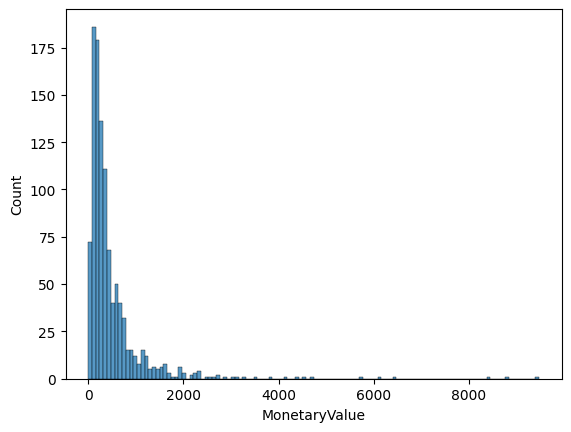

In [84]:
import seaborn as sns
sns.histplot(lost,x='MonetaryValue')

In [85]:
import plotly.express as px
px.histogram(lost,y='MonetaryValue',x='Recency')

In [86]:
DF['ClusterLabel'].value_counts()

ClusterLabel
Champions/VIPs                 164595
Enterprise / VIP Whales        114710
Hibernating / Risk of Churn     51952
At-Risk / Lost Customers        31133
New / Promising Customers       20641
Loyal Everyday Shoppers         15522
Name: count, dtype: int64

* At Risk/ Lost

In [87]:
# 1. Isolate the broken Hibernating cluster
lost_mask = DF['ClusterLabel'] == 'At-Risk / Lost Customers'

# 2. From Frequency 4-10 ,Moving Inactive whatle customer  into 'Whale' label,cause they're important for business 
# (Adjust based on your Frequency/Monetary thresholds)
DF.loc[lost_mask & (DF['Frequency'] >= 4) & (DF['Frequency'] <= 10) & (DF['MonetaryValue']>4000), 'ClusterLabel'] = 'Enterprise / VIP Whales'
# Moving to Hibernating/Risk of Churn
DF.loc[lost_mask & (DF['Frequency'] >= 4) & (DF['Frequency'] <= 10) , 'ClusterLabel'] = 'Hibernating / Risk of Churn'

# 3. From Frequency 3,moving to Hibernating
DF.loc[lost_mask & (DF['Frequency']==3) & (DF['Recency']>150) & (DF['Recency']<=240) & (DF['MonetaryValue']>1000) ,'ClusterLabel']='Hibernating / Risk of Churn'

DF.loc[lost_mask & (DF['Frequency']==3) & (DF['Recency']>240) & (DF['MonetaryValue']>1500) ,'ClusterLabel']='Hibernating / Risk of Churn'

# 4. Fromm Frequency2 ,Move long-gone users MonetaryValue>4000
DF.loc[lost_mask & (DF['Frequency'] == 2)  & (DF['MonetaryValue']>4000), 'ClusterLabel'] = 'Enterprise / VIP Whales'

DF.loc[lost_mask & (DF['Frequency']==2) & (DF['Recency']<240) & (DF['MonetaryValue']>2000),'ClusterLabel']='Hibernating / Risk of Churn'

In [88]:
DF['ClusterLabel'].value_counts()

ClusterLabel
Champions/VIPs                 164595
Enterprise / VIP Whales        114722
Hibernating / Risk of Churn     59489
At-Risk / Lost Customers        23584
New / Promising Customers       20641
Loyal Everyday Shoppers         15522
Name: count, dtype: int64

* Loyal Customers

In [95]:
loyal_mask = DF['ClusterLabel'] == 'Loyal Everyday Shoppers'

DF.loc[loyal_mask & (DF['Recency']>60) ,'ClusterLabel']='Hibernating / Risk of Churn'

In [96]:
DF['ClusterLabel'].value_counts()

ClusterLabel
Champions/VIPs                 164595
Enterprise / VIP Whales        114722
Hibernating / Risk of Churn     60075
At-Risk / Lost Customers        23584
New / Promising Customers       20641
Loyal Everyday Shoppers         14936
Name: count, dtype: int64

* Hibernating / Risk of Churn

In [105]:
loyal_mask = DF['ClusterLabel'] == 'Hibernating / Risk of Churn'

DF.loc[loyal_mask & (DF['MonetaryValue']>4000) ,'ClusterLabel']='Enterprise / VIP Whales'

In [107]:
DF['ClusterLabel'].value_counts()

ClusterLabel
Champions/VIPs                 164595
Enterprise / VIP Whales        119248
Hibernating / Risk of Churn     55549
At-Risk / Lost Customers        23584
New / Promising Customers       20641
Loyal Everyday Shoppers         14936
Name: count, dtype: int64

In [108]:
DF[DF['ClusterLabel']=='Enterprise / VIP Whales']['MonetaryValue'].min()

np.float64(3757.92)

In [109]:
# DF[(DF['ClusterLabel']=='Enterprise / VIP Whales') & (DF['MonetaryValue']<4000)].drop_duplicates(subset='Customer ID')

In [110]:
DF.to_csv(r'E:\dsProject\customerSegmentation\data\clean_Customer_RetailNw4.csv',index=False)